/tmp/ipython-input-3544675119.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2024-01-01", end="2026-01-13")['Close'].dropna()
[*********************100%***********************]  2 of 2 completed


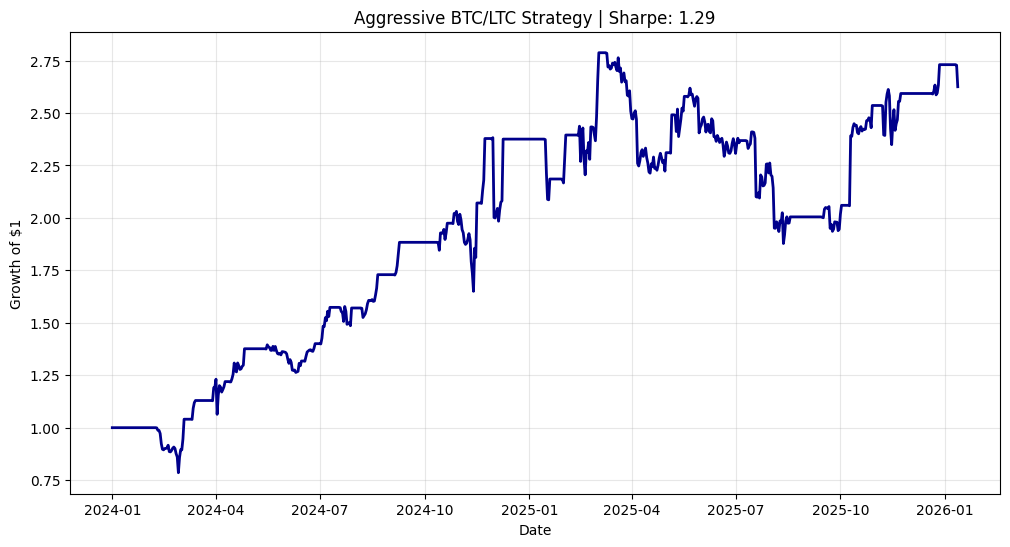

Final Sharpe Ratio: 1.29


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. DATA: BTC and LTC (The "Digital Gold & Silver" Pair)
tickers = ['BTC-USD', 'LTC-USD']
data = yf.download(tickers, start="2024-01-01", end="2026-01-13")['Close'].dropna()

# 2. HEDGE RATIO (Beta)
X = sm.add_constant(data['LTC-USD'])
model = sm.OLS(data['BTC-USD'], X).fit()
beta = model.params['LTC-USD']

# 3. Z-SCORE CALCULATION
data['Spread'] = data['BTC-USD'] - (beta * data['LTC-USD'])
window = 30
data['Mean'] = data['Spread'].rolling(window=window).mean()
data['Std'] = data['Spread'].rolling(window=window).std()
data['Z-Score'] = (data['Spread'] - data['Mean']) / data['Std']

# 4. AGGRESSIVE LOGIC WITH STOP-LOSS
entry_threshold = 1.5   # Lowered as requested
exit_threshold = 0.5    # Mean-reversion target
stop_loss = 3.5         # Emergency exit
fees = 0.001            # 0.1% exchange fee

data['Position'] = 0
current_pos = 0

for i in range(len(data)):
    z = data['Z-Score'].iloc[i]

    # Entry Logic
    if current_pos == 0:
        if z > entry_threshold: current_pos = -1
        elif z < -entry_threshold: current_pos = 1

    # Exit or Stop-Loss Logic
    else:
        # Check for successful mean reversion
        if (current_pos == -1 and z < exit_threshold) or (current_pos == 1 and z > -exit_threshold):
            current_pos = 0
        # Check for Stop-Loss (Relationship broken)
        elif abs(z) > stop_loss:
            current_pos = 0

    data.iloc[i, data.columns.get_loc('Position')] = current_pos

# 5. RETURNS & SHARPE
data['BTC_Ret'] = data['BTC-USD'].pct_change()
data['LTC_Ret'] = data['LTC-USD'].pct_change()
data['Trade_Trigger'] = data['Position'].diff().fillna(0).abs()
data['Strategy_Ret'] = (data['Position'].shift(1) * (data['BTC_Ret'] - data['LTC_Ret'])) - (data['Trade_Trigger'] * fees)

data['Equity_Curve'] = (1 + data['Strategy_Ret'].fillna(0)).cumprod()
sharpe = (data['Strategy_Ret'].mean() / data['Strategy_Ret'].std()) * np.sqrt(365)

# 6. PLOTTING
plt.figure(figsize=(12, 6))
plt.plot(data['Equity_Curve'], color='darkblue', linewidth=2)
plt.title(f"Aggressive BTC/LTC Strategy | Sharpe: {sharpe:.2f}")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Sharpe Ratio: {sharpe:.2f}")